# 1. Heart Disease Prediction using Machine Learning

## CodeAlpha Machine Learning Internship - Task 4

### Objective
The objective of this project is to develop a machine learning model that predicts whether a patient is likely to have heart disease based on various medical attributes and lifestyle factors. The project involves data preprocessing, exploratory data analysis, model training, evaluation, and comparison of multiple classification algorithms to identify the best-performing model.

## 2. Importing Required Libraries

In this section, we import all the necessary Python libraries required for data manipulation, visualization, preprocessing, model building, and evaluation throughout the project.

In [71]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report

## 3. Loading the Dataset

The dataset is loaded into a Pandas DataFrame to inspect its structure and prepare it for preprocessing and analysis.

In [2]:
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "processed.cleveland.data",
    names=column_names
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 4.Understanding the Dataset

Let's explore the dataset to understand its structure, data types, missing values, and basic statistics before preprocessing.

In [3]:
print("Shape of Dataset: ",df.shape)

print("Columns: ",df.columns)

print("Dataset Information:")
df.info()

print("Statistical Summary:")
display(df.describe())

print("Missing values:")
display(df.isnull().sum())

print("Duplicate Rows:",df.duplicated().sum())

Shape of Dataset:  (303, 14)
Columns:  Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usag

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


Missing values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 0


## 5. Data Cleaning

Handle missing values to prepare the dataset for analysis and model training.

In [4]:
print(df["ca"].unique())
print(df["thal"].unique())

['0.0' '3.0' '2.0' '1.0' '?']
['6.0' '3.0' '7.0' '?']


In [5]:
# Replace ? with with NaN
df.replace("?", np.nan, inplace=True)

#Covert to numeric
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

# check missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [6]:
# Fill missing values
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# verify
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Target Variable

The original target contains multiple classes representing different levels of heart disease. For this project, we'll convert it into a binary target where **0** indicates no heart disease and **1** indicates the presence of heart disease.

In [7]:
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 6. Exploratory Data Analysis (EDA)

Let's explore the dataset to understand the distribution of features and identify any useful patterns.

### Heart Disease Distribution

Check how the target classes are distributed in the dataset.

target
0    164
1    139
Name: count, dtype: int64


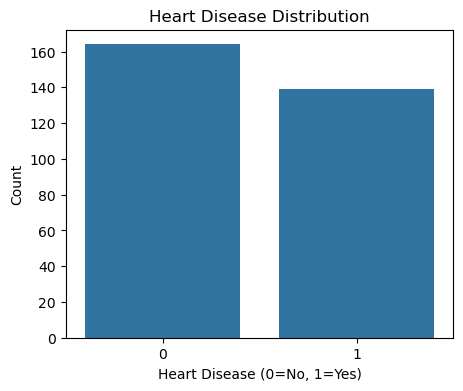

In [9]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x="target")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0=No, 1=Yes)")
plt.ylabel("Count")

print(df["target"].value_counts())

### Observations

- The dataset is fairly balanced, with a similar number of patients having and not having heart disease.
- Since both classes are well represented, the models can learn from each class effectively without requiring special techniques to handle class imbalance.

### Correlation Heatmap

Let's examine the relationships between different features and identify which ones are more closely associated with the target variable.

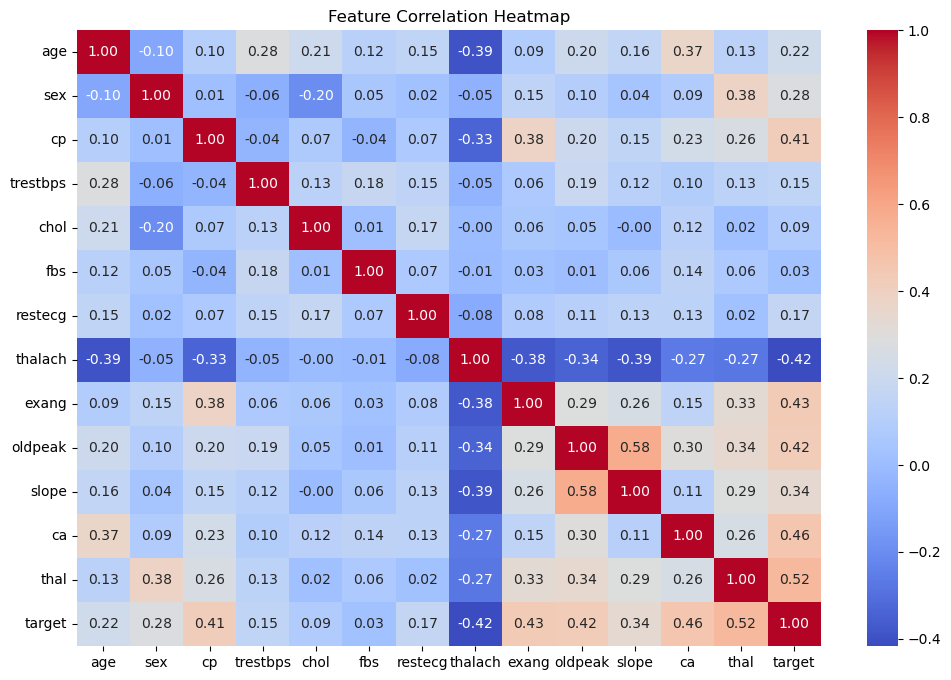

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observations

- The features **thal (0.52)**, **ca (0.46)**, **exang (0.43)**, **oldpeak (0.42)**, and **cp (0.41)** show the strongest positive correlation with heart disease.
- **Thalach (-0.42)** has the strongest negative correlation, indicating that patients with lower maximum heart rates are more likely to have heart disease.
- Most other features have weak to moderate correlations, suggesting that multiple features together contribute to the prediction rather than a single feature.

### Relation ships btw features and target

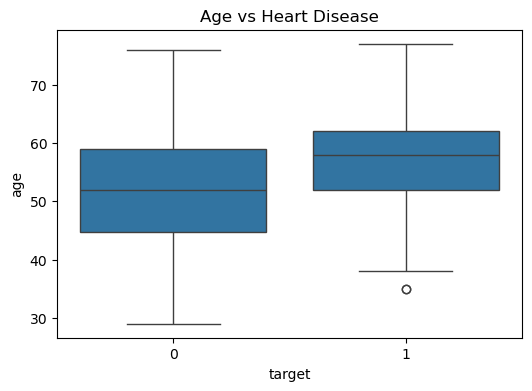

In [13]:
# Age vs target
plt.figure(figsize=(6,4))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")

plt.show()

### Observations

- Patients with heart disease tend to be older than those without heart disease.
- The median age of patients with heart disease is higher, indicating that age may be an important risk factor.

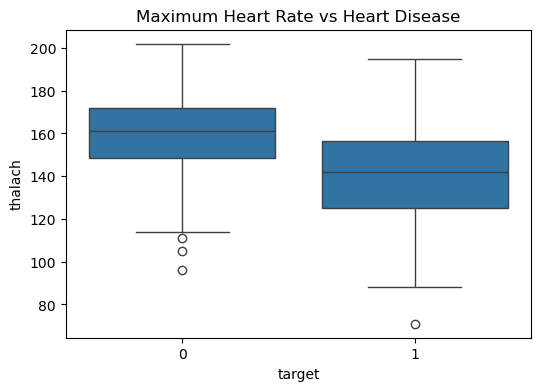

In [14]:
# maximum heart rate vs target
plt.figure(figsize=(6,4))

sns.boxplot(x="target", y="thalach", data=df)

plt.title("Maximum Heart Rate vs Heart Disease")

plt.show()

### Observations

- Patients without heart disease generally achieved a higher maximum heart rate.
- Patients with heart disease tend to have lower maximum heart rates, suggesting an inverse relationship between **thalach** and the target.

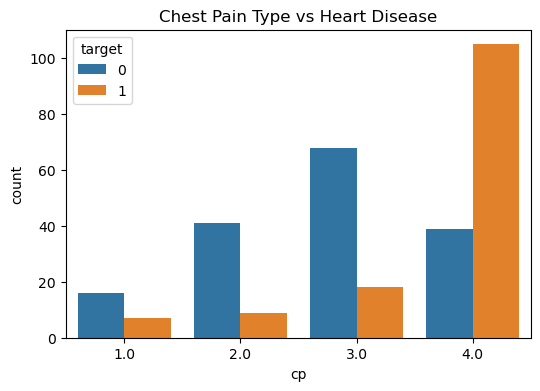

In [15]:
# chest pain type vs target
plt.figure(figsize=(6,4))

sns.countplot(x="cp", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

### Observations

- Chest pain type shows a clear relationship with heart disease.
- Patients with **cp = 4** are more likely to have heart disease, while **cp = 3** is more common among patients without heart disease.
- This indicates that chest pain type is an important feature for predicting heart disease.

## Data Preprocessing

Prepare the data for model training by splitting the dataset and applying appropriate preprocessing techniques.

## Feature Selection

Separate the input features and target variable for model training.

In [16]:
X = df.drop("target",axis=1)
y = df["target"]

print("Feature Shape:",X.shape)
print("Target Shape:",y.shape)

Feature Shape: (303, 13)
Target Shape: (303,)


## Train-Test Split

Split the dataset into training and testing sets to evaluate the model on unseen data.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

print("Training Set:",X_train.shape)
print("Testing Set:",X_test.shape)

Training Set: (242, 13)
Testing Set: (61, 13)


## Feature Scaling

Scale the numerical features to improve the performance of distance-based and linear models.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled

array([[-0.72948484,  0.68313005,  0.8701687 , ...,  0.67505958,
        -0.68971531,  1.17997269],
       [ 0.05016647,  0.68313005, -1.18427838, ..., -0.9585846 ,
        -0.68971531, -0.87806977],
       [-0.06121229, -1.46385011, -1.18427838, ..., -0.9585846 ,
         0.44573438, -0.87806977],
       ...,
       [ 1.38671155,  0.68313005,  0.8701687 , ...,  0.67505958,
         1.58118408,  1.17997269],
       [ 1.60946907,  0.68313005, -0.15705484, ...,  0.67505958,
         2.71663377,  1.17997269],
       [-0.72948484,  0.68313005, -1.18427838, ...,  2.30870375,
        -0.68971531,  1.17997269]])

## Model Evaluation Function

To keep the notebook clean and avoid repetitive code, we'll create a reusable function to evaluate each model. This function calculates the key performance metrics and displays the confusion matrix and classification report for every model.

In [23]:
results = []

def evaluate_model(model_name,y_test,y_pred,y_prob):
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_prob)

    results.append({
        "Model":model_name,
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,
        "F1-score":f1,
        "ROC-AUC":roc_auc
    })

    print(model_name)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    cm = confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

    print("Classification report:")
    print(classification_report(y_test,y_pred))

# 7. Building Baseline Models

Now that the data is preprocessed, we can train our machine learning models. We will first build baseline models using their default parameters to establish a performance benchmark. Later, we'll compare their results and fine-tune the best-performing models.

### Logistic Regression

Logistic Regression is a simple yet effective classification algorithm that serves as a strong baseline for binary classification problems.

In [20]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled,y_train)

LogisticRegression(random_state=42)

In [21]:
lr_pred = lr_model.predict(X_test_scaled)

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

### Model Evaluation

Evaluate the Logistic Regression model using multiple performance metrics to assess its classification performance.

Logistic Regression
Accuracy: 0.8689
Precision: 0.8125
Recall: 0.9286
F1-Score: 0.8667
ROC-AUC: 0.9513
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



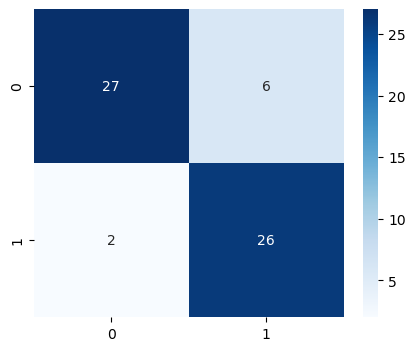

In [24]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

### Observations

- Logistic Regression achieved an **accuracy of 86.89%**, providing a strong baseline for heart disease prediction.
- The model correctly identified **26 out of 28** patients with heart disease, resulting in a **high recall of 92.86%**.
- The **precision of 81.25%** indicates that most patients predicted as having heart disease were correctly classified.
- The **ROC-AUC score of 95.13%** demonstrates excellent class discrimination, showing that the model effectively distinguishes between patients with and without heart disease.
- Overall, Logistic Regression performs well on this dataset and establishes a strong baseline for comparison with the remaining models.

### Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful classification algorithm that finds the optimal decision boundary to separate different classes. It is particularly effective for complex datasets and often performs well after feature scaling.

In [25]:
svm_model = SVC(
    random_state=42,
    probability=True
)

svm_model.fit(X_train_scaled,y_train)

SVC(probability=True, random_state=42)

In [26]:
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:,1]

### Model Evaluation

Evaluate the Support Vector Machine model using multiple performance metrics to assess its classification performance.

Support Vector Machine
Accuracy: 0.8525
Precision: 0.8065
Recall: 0.8929
F1-Score: 0.8475
ROC-AUC: 0.9437
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



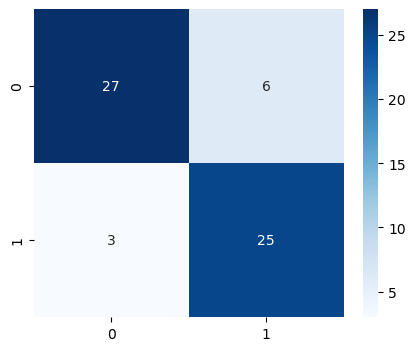

In [27]:
# Evaluation

evaluate_model(
    "Support Vector Machine",
    y_test,
    svm_pred,
    svm_prob
    
)

### Observations

- Support Vector Machine achieved an **accuracy of 85.25%**, demonstrating strong classification performance on the dataset.
- The model achieved a **recall of 89.29%**, successfully identifying most patients with heart disease.
- With a **precision of 80.65%** and an **F1-score of 84.75%**, the model maintained a good balance between identifying positive cases and minimizing false predictions.
- The **ROC-AUC score of 94.37%** indicates excellent class discrimination and reliable predictive performance.
- Overall, SVM performed well; however, Logistic Regression achieved slightly better results across all evaluation metrics.

### Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is capable of capturing complex, non-linear relationships between features, making it a strong choice for classification tasks.

In [28]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [29]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

### Model Evaluation

Evaluate the Random Forest model using multiple performance metrics to understand its classification performance and compare it with the previous baseline models.

Random Forest
Accuracy: 0.8852
Precision: 0.8387
Recall: 0.9286
F1-Score: 0.8814
ROC-AUC: 0.9518
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



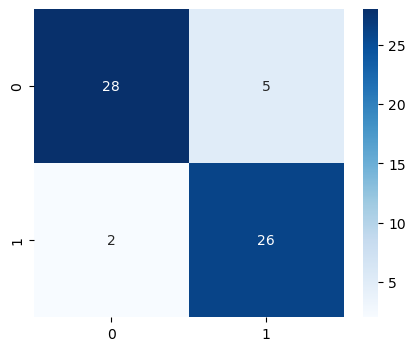

In [30]:
# Evaluation
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

### Observations

- Random Forest achieved the **highest accuracy of 88.52%** among the baseline models evaluated so far.
- The model correctly identified **26 out of 28** patients with heart disease, resulting in a **high recall of 92.86%**.
- With a **precision of 83.87%** and an **F1-score of 88.14%**, the model demonstrated an excellent balance between identifying positive cases and minimizing false predictions.
- The **ROC-AUC score of 95.18%** indicates excellent class discrimination and reliable predictive performance.
- Overall, Random Forest outperformed both Logistic Regression and Support Vector Machine, making it the strongest baseline model at this stage.

### Feature Importance

Random Forest provides feature importance scores, allowing us to identify which features contribute the most to heart disease prediction. Understanding feature importance helps improve model interpretability and provides insights into the factors influencing the model's decisions.

In [38]:
# Feature importance
feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [41]:
feature_importance.head()

,Feature,Importance
7,thalach,0.135404
2,cp,0.127163
12,thal,0.122940
11,ca,0.100811
0,age,0.091327


Text(0, 0.5, 'Features')

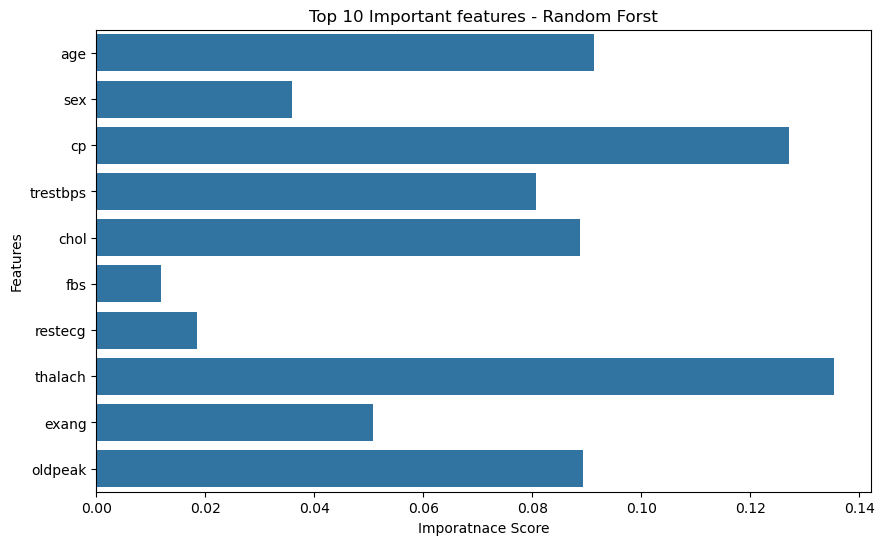

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_impotance.head(10),
    y="Feature",
    x="Importance"
)

plt.title("Top 10 Important features - Random Forst")
plt.xlabel("Imporatnace Score")
plt.ylabel("Features")

### Observations

- **Thalach (Maximum Heart Rate)** is the most important feature, indicating that it has the strongest influence on the Random Forest model's predictions.
- **Chest Pain Type (cp)** is the second most important feature, highlighting its significant role in identifying heart disease.
- Features such as **age**, **oldpeak**, **cholesterol (chol)**, and **resting blood pressure (trestbps)** also contribute considerably to the prediction.
- Features like **fasting blood sugar (fbs)** and **resting ECG (restecg)** have relatively low importance, suggesting a smaller impact on the model's decisions.
- Overall, the model relies on a combination of clinical measurements rather than a single feature to predict heart disease.

### XGBoost

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds trees sequentially, where each new tree corrects the errors of the previous ones. It is known for its high predictive performance, efficiency, and ability to handle complex patterns in structured data.

In [53]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)


xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Model Evaluation

Evaluate the XGBoost model using multiple performance metrics and compare its performance with the other baseline models.

In [54]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

### Model Evaluation

Evaluate the XGBoost model using multiple performance metrics and compare its performance with the other baseline models.

XGBoost
Accuracy: 0.8525
Precision: 0.7879
Recall: 0.9286
F1-Score: 0.8525
ROC-AUC: 0.9188
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



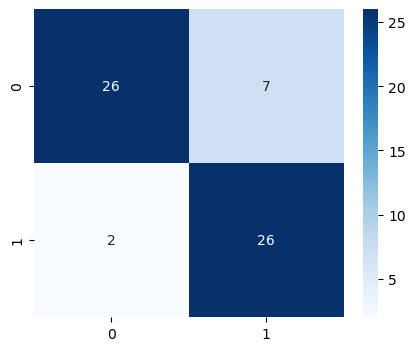

In [59]:
evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

In [57]:
results.pop()

{'Model': 'XGBoost',
 'Accuracy': 0.8524590163934426,
 'Precision': 0.7878787878787878,
 'Recall': 0.9285714285714286,
 'F1-score': 0.8524590163934426,
 'ROC-AUC': np.float64(0.9188311688311689)}

In [58]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8688524590163934,
  'Precision': 0.8125,
  'Recall': 0.9285714285714286,
  'F1-score': 0.8666666666666667,
  'ROC-AUC': np.float64(0.9512987012987013)},
 {'Model': 'Support Vector Machine',
  'Accuracy': 0.8524590163934426,
  'Precision': 0.8064516129032258,
  'Recall': 0.8928571428571429,
  'F1-score': 0.847457627118644,
  'ROC-AUC': np.float64(0.9437229437229437)},
 {'Model': 'Random Forest',
  'Accuracy': 0.8852459016393442,
  'Precision': 0.8387096774193549,
  'Recall': 0.9285714285714286,
  'F1-score': 0.8813559322033898,
  'ROC-AUC': np.float64(0.9518398268398268)}]

## Baseline Model Comparison

The performance of all baseline models was compared using multiple evaluation metrics. Among the four models, **Random Forest** achieved the best overall performance, with the highest Accuracy, Precision, F1-Score, and ROC-AUC. Logistic Regression also performed strongly, while SVM and XGBoost produced competitive results but fell slightly behind the top-performing model.

In [61]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

In [62]:
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,XGBoost,0.852459,0.787879,0.928571,0.852459,0.918831
3,Support Vector Machine,0.852459,0.806452,0.892857,0.847458,0.943723


### Observations

- All four baseline models achieved strong classification performance, with an accuracy above **85%**.
- **Random Forest** achieved the best overall performance, recording the highest Accuracy (**88.52%**), Precision (**83.87%**), F1-Score (**88.14%**), and ROC-AUC (**95.18%**).
- **Logistic Regression** delivered competitive results despite being the simplest model, making it a strong baseline classifier.
- **Support Vector Machine** and **XGBoost** also performed well but showed slightly lower overall performance compared to Random Forest.
- Based on the baseline evaluation, **Random Forest** and **XGBoost** will be selected for hyperparameter tuning to further improve model performance.

In [63]:
baseline_results = results_df.copy()

baseline_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,XGBoost,0.852459,0.787879,0.928571,0.852459,0.918831
3,Support Vector Machine,0.852459,0.806452,0.892857,0.847458,0.943723


# 8. Hyperparameter Tuning

Baseline models provide a good starting point, but their performance can often be improved by optimizing their hyperparameters. In this phase, we'll use **RandomizedSearchCV** to search for the best combination of parameters and evaluate whether tuning improves the model's performance.

## Hyperparameter Tuning - Random Forest

We'll optimize the Random Forest model by searching across multiple combinations of hyperparameters. RandomizedSearchCV is used because it is computationally efficient while still exploring a wide range of parameter values.

In [69]:
from scipy.stats import randint

rf_params={
    "n_estimators":randint(100,500),
    "max_depth":randint(2,20),
    "min_samples_split":randint(2,10),
    "max_features":["sqrt","log2",None],
    "bootstrap":[True,False]
}

In [78]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=100,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)
rf_random.fit(X_train,y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B4A0CC3360>,
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B4A3AE5010>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B4A0CC3100>},
                   random_state=42, scoring='recall')

### Best Hyperparameters

After exploring multiple parameter combinations, RandomizedSearchCV selected the following configuration as the best-performing Random Forest model.

In [79]:
print("Best Parameters:")
print(rf_random.best_params_)

Best Parameters:
{'bootstrap': False, 'max_depth': 6, 'max_features': 'log2', 'min_samples_split': 6, 'n_estimators': 417}


In [82]:
# Best ta
best_rf = rf_random.best_estimator_

rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_prob = best_rf.predict_proba(X_test)[:,1]

### Model Evaluation

Evaluate the tuned Random Forest model and compare its performance with the baseline model.

Random Forest (Tuned)
Accuracy: 0.9180
Precision: 0.8710
Recall: 0.9643
F1-Score: 0.9153
ROC-AUC: 0.9621
Classification report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



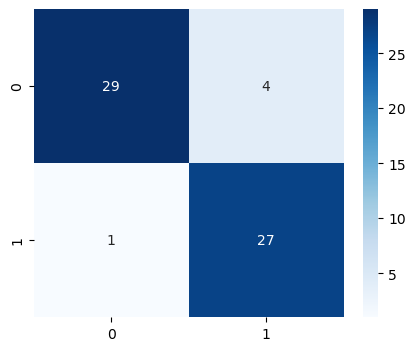

In [83]:
evaluate_model(
    "Random Forest (Tuned)",
    y_test,
    rf_tuned_pred,
    rf_tuned_prob
)

### Observations

- Hyperparameter tuning significantly improved the Random Forest model's performance across all evaluation metrics.
- The tuned model achieved an **accuracy of 91.80%**, outperforming the baseline Random Forest model.
- The **recall increased to 96.43%**, meaning the model correctly identified **27 out of 28** patients with heart disease while missing only one patient.
- The **ROC-AUC score improved to 96.21%**, indicating excellent discrimination between patients with and without heart disease.
- Overall, the tuned Random Forest model provides a better balance between accuracy and disease detection, making it a strong candidate for the final model.

## Hyperparameter Tuning - XGBoost

In this step, we'll optimize the XGBoost model using **RandomizedSearchCV**. The objective is to improve the model's ability to correctly identify patients with heart disease by maximizing the **Recall** score.

In [84]:
from scipy.stats import randint, uniform

# Hyperparameter search space
xgb_params = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),   # 0.01 - 0.30
    "subsample": uniform(0.6, 0.4),          # 0.6 - 1.0
    "colsample_bytree": uniform(0.6, 0.4),   # 0.6 - 1.0
    "gamma": uniform(0, 5),
    "min_child_weight": randint(1, 10)
}

In [85]:
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_params,
    n_iter=100,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B4A1446690>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B4A1469E50>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B4A044EE00>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001B4A3496D50>},
                   random_state=42, scoring='recall')

### Best Hyperparameters

RandomizedSearchCV explored multiple hyperparameter combinations and selected the configuration that achieved the highest Recall score during cross-validation.

In [87]:
print("Best Parameters:")
print(xgb_random.best_params_)

Best Parameters:
{'colsample_bytree': np.float64(0.6180909155642152), 'gamma': np.float64(1.6266516538163218), 'learning_rate': np.float64(0.12271641400994977), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 379, 'subsample': np.float64(0.7427013306774357)}


In [88]:
# Best XGBoost model
best_xgb = xgb_random.best_estimator_

# Predictions
xgb_tuned_pred = best_xgb.predict(X_test)
xgb_tuned_prob = best_xgb.predict_proba(X_test)[:, 1]

### Model Evaluation

Evaluate the tuned XGBoost model and compare its performance with the baseline model.

XGBoost (Tuned)
Accuracy: 0.8689
Precision: 0.8333
Recall: 0.8929
F1-Score: 0.8621
ROC-AUC: 0.9545
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



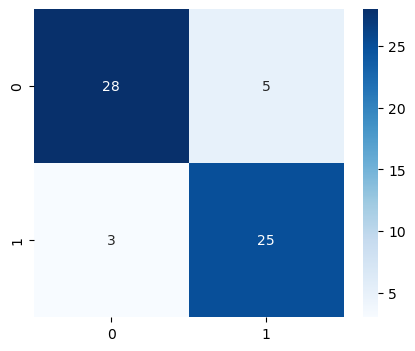

In [89]:
evaluate_model(
    "XGBoost (Tuned)",
    y_test,
    xgb_tuned_pred,
    xgb_tuned_prob
)

### Observations

- Hyperparameter tuning improved the overall performance of the XGBoost model, increasing its Accuracy, Precision, F1-Score, and ROC-AUC.
- The tuned model achieved an **accuracy of 86.89%** and an **ROC-AUC of 95.45%**, indicating stronger overall classification performance.
- The **precision improved to 83.33%**, reducing the number of false positive predictions.
- Although the model was optimized using Recall as the scoring metric, the **test recall decreased slightly** from **92.86%** to **89.29%**. This can occur because hyperparameter tuning is based on cross-validation performance and may not always produce the highest recall on a separate test set.
- Overall, the tuned XGBoost model performed better than the baseline in most evaluation metrics, but the tuned Random Forest remained the best-performing model.

In [91]:
final_df = pd.DataFrame(results)

final_df = final_df.sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

In [92]:
final_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest (Tuned),0.918033,0.870968,0.964286,0.915254,0.962121
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,XGBoost,0.852459,0.787879,0.928571,0.852459,0.918831
3,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
4,Support Vector Machine,0.852459,0.806452,0.892857,0.847458,0.943723
5,XGBoost (Tuned),0.868852,0.833333,0.892857,0.862069,0.954545


# 9. Saving the Best Model

After evaluating all baseline and tuned models, the **Tuned Random Forest** model achieved the best overall performance. The trained model is saved so it can be reused later without retraining.

In [93]:
import joblib

# Save the best model

joblib.dump(best_rf,"heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# 10. Final Performance Summary

The table below summarizes the performance of all evaluated machine learning models, including both baseline and tuned versions.

In [94]:
final_df.style.format({
    "Accuracy":"{:.4f}",
    "Precision":"{:.4f}",
    "Recall":"{:.4f}",
    "F1-Score":"{:.4f}",
    "ROC-AUC":"{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest (Tuned),0.9180,0.8710,0.9643,0.915254,0.9621
1,Logistic Regression,0.8689,0.8125,0.9286,0.866667,0.9513
2,XGBoost,0.8525,0.7879,0.9286,0.852459,0.9188
3,Random Forest,0.8852,0.8387,0.9286,0.881356,0.9518
4,Support Vector Machine,0.8525,0.8065,0.8929,0.847458,0.9437
5,XGBoost (Tuned),0.8689,0.8333,0.8929,0.862069,0.9545


# 11. Conclusion

In this project, multiple machine learning algorithms were developed and evaluated to predict the presence of heart disease using the UCI Heart Disease dataset.

The workflow included data cleaning, exploratory data analysis, preprocessing, feature scaling, baseline model development, hyperparameter tuning, and model evaluation.

Among all the evaluated models, the **Tuned Random Forest** achieved the best overall performance with:

- **Accuracy:** 91.80%
- **Precision:** 87.10%
- **Recall:** 96.43%
- **F1-Score:** 91.53%
- **ROC-AUC:** 96.21%

Since this is a medical diagnosis problem, **Recall** was considered the most important evaluation metric because correctly identifying patients with heart disease is more critical than minimizing false positive predictions.

Overall, the Tuned Random Forest model demonstrated excellent predictive performance and is selected as the final model for heart disease prediction.

# 12. Future Improvements

- Train the model on larger and more diverse heart disease datasets.
- Perform feature engineering to improve predictive performance.
- Experiment with advanced hyperparameter optimization techniques such as Bayesian Optimization or Optuna.
- Build a web application using Flask or Streamlit for real-time heart disease prediction.
- Validate the model on external datasets to evaluate its generalization capability.

# 13. Key Learnings
- Learned how to clean and preprocess real-world healthcare data.
- Performed exploratory data analysis to identify important patterns.
- Compared multiple machine learning algorithms using appropriate evaluation metrics.
- Applied RandomizedSearchCV for hyperparameter tuning.
- Understood the importance of selecting evaluation metrics based on the application domain.
- Built and saved the best-performing model for future use.